In [1]:
from watts.plugin_cyclus import ResultsCyclus

In [2]:
from watts.parameters import Parameters
from watts.results import ExecInfo, Results
from watts.plugin_cyclus import CyclusOutput
inputs = []
outputs = ['./nuc46_nz50_ot1.sqlite']

obj = ResultsCyclus(Parameters(), ExecInfo(1, 'cyclus', 'name', 1),
                    inputs, outputs)

In [3]:
r = obj.obj.cur.execute('SELECT distinct(commodity) FROM transactions')

In [4]:
[x['commodity'] for x in r]

['natl_u', 'uox', 'tailings', 'uox_waste', 'ap1000_uox', 'uox_waste_ap1000']

In [5]:
reactors = obj.reactors

In [6]:
named_reactors = ['AP1000', 'VOYGR', '12VOYGR' 'Natrium', 'XE100', '4XE100']

In [7]:
legacy_protos = [q for q in obj.reactors.values() if q not in named_reactors]



In [8]:
def aggregate_smr(d):
    # 4XE100 and 12VOYGR
    # because we can't have that many agents deployed
    if '12VOYGR' in d:
        if 'VOYGR' in d:
            d['VOYGR'] += d.pop('12VOYGR')
        else:
            d['VOYGR'] = d.pop('12VOYGR')
    if '4XE100' in d:
        if 'XE100' in d:
            d['XE100'] += d.pop('4XE100')
        else:
            d['XE100'] = d.pop('4XE100')
    return d

In [9]:
data_dict = {}

In [10]:
import numpy as np
which = 'natu'
data_dict[which] = {}
for proto in named_reactors:
    if proto in reactors.values():
        data_dict[which][proto] = obj.obj.stock_fuel_natu(proto, 0.00711, 0.0025)

data_dict[which]['legacy'] = obj.obj.stock_fuel_natu(legacy_protos, 0.00711, 0.0025)

data_dict[which] = aggregate_smr(data_dict[which])


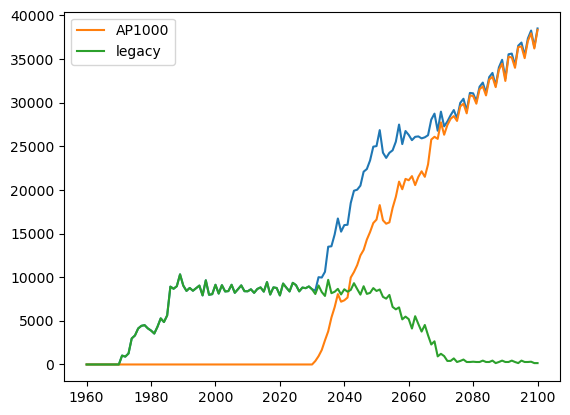

In [11]:
import matplotlib.pyplot as plt
plt.plot(obj.time_dict['years'][::12], sum(data_dict[which].values())/1e3)
for k,v in data_dict[which].items():
    plt.plot(obj.time_dict['years'][::12], v/1e3, label=k)
plt.legend()

In [12]:
import numpy as np
which = 'swu'
data_dict[which] = {}
for proto in named_reactors:
    if proto in reactors.values():
        data_dict[which][proto] =  obj.obj.stock_fuel_swu(proto, 0.00711, 0.0025)

data_dict[which]['legacy'] = obj.obj.stock_fuel_swu(legacy_protos, 0.00711, 0.0025)

data_dict[which] = aggregate_smr(data_dict[which])



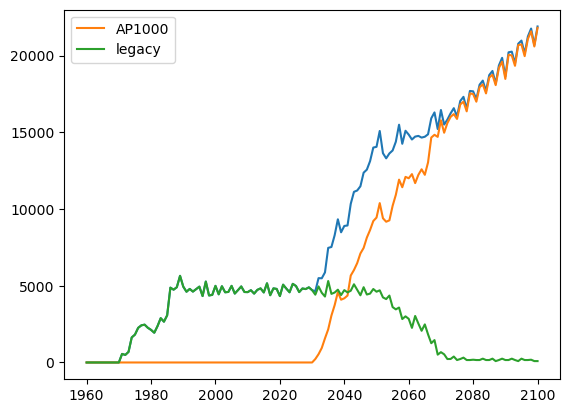

In [13]:
import matplotlib.pyplot as plt
plt.plot(obj.time_dict['years'][::12], sum(data_dict[which].values())/1e3)
for k,v in data_dict[which].items():
    plt.plot(obj.time_dict['years'][::12], v/1e3, label=k)
plt.legend()

In [ ]:
# get fuel demand
which = 'fuel'
data_dict[which] = {}
for proto in named_reactors:
    if proto in reactors.values():
        data_dict[which][proto] = obj.obj.process_prototype(proto, False)[1]['receiving']
        data_dict[which][proto] = list(data_dict[which][proto].values())[0]

data_dict[which]['legacy'] = sum(obj.obj.process_prototype(legacy_protos, False)[1]['receiving'].values())


data_dict[which] = aggregate_smr(data_dict[which])


In [ ]:
from watts.enr_utils import calculate_swu_split_cats
swu = calculate_swu_split_cats(0.00711, 0.0025, 0.18)
swu

In [ ]:
xx = data_dict['fuel']['AP1000'] * swu[:, None]

In [ ]:
swu

In [ ]:
xx[2,:]

In [ ]:
(swu * data_dict['fuel']['AP1000'][:, None]).shape

In [ ]:
swu = np.zeros((len(swu), len(fuel))
np.multiply(swu, data_dict['fuel']['AP1000'], )

In [ ]:
test = obj.obj.process_prototype(['VOGTLE-3', 'VOGTLE-4'],
                          False)[1]['receiving']

In [ ]:
# treating vogtle as not legacy
test['ap1000_uox'] + data_dict['fuel']['AP1000']

In [ ]:
data_dict['fuel']['AP1000']

In [ ]:
import matplotlib.pyplot as plt
plt.plot(obj.time_dict['years'][::12], sum(data_dict[which].values())/1e3)
for k,v in data_dict[which].items():
    plt.plot(obj.time_dict['years'][::12], v/1e3, label=k)
plt.legend()